# Custom class
> to calculate b and m as well

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [22]:
from sklearn.datasets import make_regression
x,y = make_regression(n_samples=100, n_features=1, n_informative=1, n_targets=1, noise = 20, random_state=2)

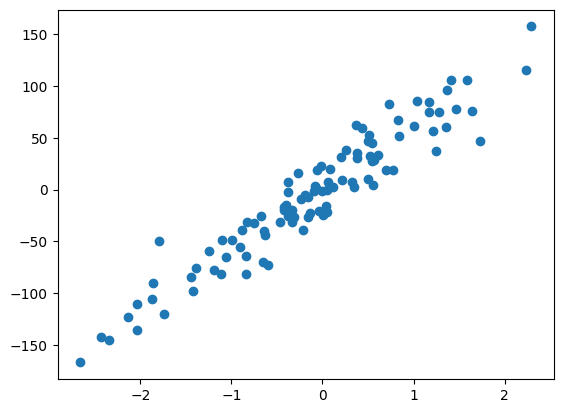

In [23]:
plt.scatter(x,y)

In [24]:
# getting m and b to verify with custom class
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2, random_state=2)

In [25]:
# model training
from sklearn.linear_model import LinearRegression
lr = LinearRegression()
lr.fit(x_train,y_train)

LinearRegression()

In [26]:
print(lr.coef_) # (m)
print(lr.intercept_) # (b)

[57.25933739]
-0.20094647599604976


In [27]:
y_pred = lr.predict(x_test)

In [28]:
from sklearn.metrics import r2_score
r2 = r2_score(y_test,y_pred)
r2

0.9095184055289018

### class GD

In [29]:
class GD:
    def __init__(self, learning_rate, epochs):
        self.m = 0 # random values for m and b
        self.b = 0
        self.n = learning_rate
        self.epochs = epochs
    
    def fit(self, x_train, y_train):
        for i in range(self.epochs):
            loss_slope_b = (-2/x_train.shape[0]) * np.sum(y_train - self.m * x_train.ravel() - self.b)
            loss_slope_m = (-2/x_train.shape[0]) * np.sum((y_train - self.m * x_train.ravel() - self.b) * x_train.ravel())

            self.b = self.b - (self.n * loss_slope_b)
            self.m = self.m - (self.n * loss_slope_m)

        print('b = ',self.b)
        print('m = ',self.m)

    def predict(self,x_test):
        return self.m * x_test + self.b

In [31]:
gd = GD(0.01, 500)
gd.fit(x_train, y_train)

b =  -0.20317226570851143
m =  57.25795388974439


In [32]:
y_pred_gd = gd.predict(x_test)
r2_score_gd = r2_score(y_test, y_pred_gd)
r2_score_gd

0.9095095188190907